In [7]:
import torch
import sys

print(f"Python Version: {sys.version}")
print(f"PyTorch Version: {torch.__version__}")
print(f"CUDA Available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    x = torch.ones(1).cuda()
    print(f"GPU Test: Successful")
else:
    print("GPU Test: CUDA not detected. Check NVIDIA drivers.")

Python Version: 3.12.12 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 20:05:38) [MSC v.1929 64 bit (AMD64)]
PyTorch Version: 2.5.1
CUDA Available: True
GPU Name: NVIDIA GeForce RTX 4060 Laptop GPU
GPU Test: Successful


In [24]:
import torch
import torch.nn as nn
from PIL import Image, ImageDraw
import torchvision.transforms as T
import numpy as np

# 1. Setup paths - CHANGE THESE
MODEL_PATH = 'C:/Users/jazzb/rt-deterv2/RT-DETRv2/output/rtdetrv2_r50vd_m_6x_coco/best.pth'
IMAGE_PATH = 'C:/Users/jazzb/rt-deterv2/RT-DETRv2/dataset/DPWH-sample-Dataset/testing/d0adef8d-4_-__Potholes_16.png' 
OUTPUT_NAME = 'detection_result.jpg'

# 2. Load the model manually (Avoids the 'str' issue)
from src.core import YAMLConfig
import torch

cfg = YAMLConfig('configs/rtdetrv2/rtdetrv2_r50vd_m_7x_coco.yml', resume=MODEL_PATH)
model = cfg.model # Use the raw model architecture
checkpoint = torch.load(MODEL_PATH, map_location='cpu')

# If 'ema' exists in the checkpoint, use it (it's usually more accurate)
if 'ema' in checkpoint:
    state_dict = checkpoint['ema']['module']
elif 'model' in checkpoint:
    state_dict = checkpoint['model']
else:
    state_dict = checkpoint

model.load_state_dict(state_dict)
model.eval()

# 3. Prepare Image
img_pil = Image.open(IMAGE_PATH).convert('RGB')
w, h = img_pil.size
# RT-DETR usually expects 640x640
transforms = T.Compose([
    T.Resize((640, 640)),
    T.ToTensor(),
])
img_tensor = transforms(img_pil).unsqueeze(0) # Add batch dimension

# 4. Run Inference
with torch.no_grad():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model.to(device)
    img_tensor = img_tensor.to(device)
    
    outputs = model(img_tensor)
    
    # RT-DETR raw output is often a dict with 'pred_logits' and 'pred_boxes'
    if isinstance(outputs, dict):
        logits = outputs['pred_logits']
        boxes = outputs['pred_boxes']
        # Convert logits to probabilities and get labels
        probs = logits.sigmoid()
        scores, labels = probs.max(-1)
    else:
        # If it's a list/tuple, filter out strings to find the tensors
        tensors = [t for t in outputs if torch.is_tensor(t)]
        # Usually: [labels_tensor, boxes_tensor, scores_tensor]
        if len(tensors) == 3:
            labels, boxes, scores = tensors
        elif len(tensors) == 2:
            labels, boxes = tensors
            scores = torch.ones_like(labels).float()
        else:
            raise ValueError(f"Could not find tensors in output. Types: {[type(o) for o in outputs]}")

# 5. Drawing (Safe Unpacking)
draw = ImageDraw.Draw(img_pil)

# Ensure they are tensors before calling .cpu()
def to_numpy(x):
    if torch.is_tensor(x):
        return x[0].cpu().numpy() # Take first batch
    return x

labels_np = to_numpy(labels)
boxes_np = to_numpy(boxes)
scores_np = to_numpy(scores)

# Road Damage Classes

class_map = {
    0: "Alligator Cracks",
    1: "Cracks",
    2: "Open Manhole",
    3: "Potholes",
    4: "Ravelling"
}
count = 0

for i in range(len(boxes_np)):
    scr = scores_np[i]
    if scr > 0.3: # confidence score
        count += 1
        # Handle if label is numeric or string
        label_val = labels_np[i]
        label_name = class_map.get(int(label_val), f"CLS_{label_val}")
        
        # [cx, cy, w, h] normalized -> [L, T, R, B]
        cx, cy, bw, bh = boxes_np[i]
        left = (cx - bw/2) * w
        top = (cy - bh/2) * h
        right = (cx + bw/2) * w
        bottom = (cy + bh/2) * h
        
        draw.rectangle([left, top, right, bottom], outline="red", width=4)
        draw.text((left, top - 15), f"{label_name} {scr:.2f}", fill="red")

img_pil.save(OUTPUT_NAME)
print(f" Detection complete! Found {count} objects. Saved to {OUTPUT_NAME}")

Load PResNet50 state_dict


C:\Users\jazzb\AppData\Local\Temp\ipykernel_15004\76216861.py:18: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(MODEL_PATH, map_location='cpu')


 Detection complete! Found 2 objects. Saved to detection_result.jpg


In [23]:
import json
import os
from collections import Counter

# Path to your DPWH training file
train_json_path = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train.json'

with open(train_json_path, 'r') as f:
    data = json.load(f)

# 1. Check Categories
print("--- Categories Found ---")
categories = {cat['id']: cat['name'] for cat in data['categories']}
for cat_id, cat_name in categories.items():
    print(f"ID: {cat_id} | Name: {cat_name}")

# 2. Count Images
print(f"\nTotal Images: {len(data['images'])}")

# 3. Count Annotations per Class
print("\n--- Distribution of Labels ---")
label_counts = Counter([ann['category_id'] for ann in data['annotations']])

for cat_id, count in label_counts.items():
    name = categories.get(cat_id, "Unknown")
    print(f"{name} (ID {cat_id}): {count} instances")

# 4. Check for Empty Images
annotated_img_ids = {ann['image_id'] for ann in data['annotations']}
all_img_ids = {img['id'] for img in data['images']}
empty_images = all_img_ids - annotated_img_ids
print(f"\nImages without any labels: {len(empty_images)}")

--- Categories Found ---
ID: 0 | Name: Alligator Cracks
ID: 1 | Name: Cracks
ID: 2 | Name: Open Manhole
ID: 3 | Name: Potholes
ID: 4 | Name: Ravelling

Total Images: 70

--- Distribution of Labels ---
Cracks (ID 1): 23 instances
Potholes (ID 3): 21 instances
Alligator Cracks (ID 0): 16 instances
Open Manhole (ID 2): 13 instances
Ravelling (ID 4): 18 instances

Images without any labels: 0


In [9]:
import json
import os

# 1. List all the JSON files you want to fix
json_paths = [
    r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train.json',
    r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\validation\instances_validation.json',
    r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\testing\instances_testing.json' # Added testing too!
]

for j_path in json_paths:
    if not os.path.exists(j_path):
        print(f"⚠️ Skipping: {j_path} (File not found)")
        continue

    # Get the folder where the images actually are
    img_folder = os.path.dirname(j_path)
    actual_files = os.listdir(img_folder)
    # Create a lowercase map for case-insensitive matching (fixes .png vs .PNG)
    file_map = {f.lower(): f for f in actual_files}

    with open(j_path, 'r') as f:
        data = json.load(f)

    print(f"Processing: {os.path.basename(j_path)}...")
    fixed_count = 0

    # 2. Strip path and fix case-sensitivity
    for img in data['images']:
        original_name = os.path.basename(img['file_name'])
        
        # Check if the file exists in the folder (case-insensitive)
        if original_name.lower() in file_map:
            img['file_name'] = file_map[original_name.lower()]
            fixed_count += 1
        else:
            # If not found, at least strip the path
            img['file_name'] = original_name

    # 3. Save the fixed version
    fixed_json_path = j_path.replace('.json', '_fixed.json')
    with open(fixed_json_path, 'w') as f:
        json.dump(data, f)

    print(f"✅ Done! Saved {fixed_count} fixed filenames to: {os.path.basename(fixed_json_path)}\n")

print("--- ALL FILES CLEANED ---")

Processing: instances_train.json...
✅ Done! Saved 70 fixed filenames to: instances_train_fixed.json

Processing: instances_validation.json...
✅ Done! Saved 10 fixed filenames to: instances_validation_fixed.json

Processing: instances_testing.json...
✅ Done! Saved 20 fixed filenames to: instances_testing_fixed.json

--- ALL FILES CLEANED ---


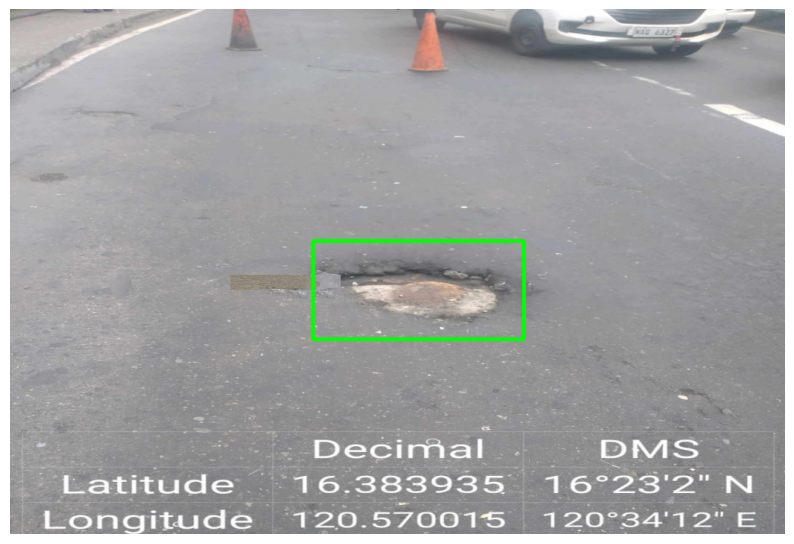

In [4]:
import cv2
import json
import os
import matplotlib.pyplot as plt

# --- CONFIGURATION ---
json_path = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'
img_folder = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train'
# MATCH THE JSON EXACTLY (Case Sensitive)
target_image = "62771d83-4_-__Potholes_14.PNG" 

with open(json_path, 'r') as f:
    coco_data = json.load(f)

img_id = next((img['id'] for img in coco_data['images'] if img['file_name'] == target_image), None)

if img_id is None:
    print(f"❌ Error: Still can't find {target_image}. Check for hidden spaces!")
else:
    full_img_path = os.path.join(img_folder, target_image)
    image = cv2.imread(full_img_path)

    if image is None:
        # Try lowercase extension if loading fails
        image = cv2.imread(full_img_path.replace('.PNG', '.png'))

    if image is not None:
        for ann in coco_data['annotations']:
            if ann['image_id'] == img_id:
                x, y, w, h = ann['bbox']
                cv2.rectangle(image, (int(x), int(y)), (int(x + w), int(y + h)), (0, 255, 0), 3)

        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(10, 10))
        plt.imshow(image_rgb)
        plt.axis('off')
        plt.show()
    else:
        print("❌ Physical image file not found on disk.")

In [11]:
import json
import os
import random
import numpy as np
from sklearn.model_selection import KFold

# --- CONFIGURATION ---
# Use the 'fixed' JSON you just created
input_json = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'
output_dir = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\kfold_splits'

os.makedirs(output_dir, exist_ok=True)

# 1. Load the master training data
with open(input_json, 'r') as f:
    coco_data = json.load(f)

images = coco_data['images']
annotations = coco_data['annotations']
categories = coco_data['categories']

# Shuffle images to ensure folds are diverse
random.seed(42)
random.shuffle(images)

# 2. Setup K-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print(f"Total images to split: {len(images)}")

for fold, (train_idx, val_idx) in enumerate(kf.split(images)):
    # Split images
    train_imgs = [images[i] for i in train_idx]
    val_imgs = [images[i] for i in val_idx]
    
    # Function to grab annotations belonging to specific images
    def filter_annotations(image_list, all_anns):
        img_ids = {img['id'] for img in image_list}
        return [ann for ann in all_anns if ann['image_id'] in img_ids]

    # Create Fold JSON structures
    for split_name, split_imgs in [('train', train_imgs), ('val', val_imgs)]:
        subset_data = {
            "images": split_imgs,
            "annotations": filter_annotations(split_imgs, annotations),
            "categories": categories,
            "info": coco_data.get('info', {}),
            "licenses": coco_data.get('licenses', [])
        }
        
        output_filename = f"fold_{fold + 1}_{split_name}.json"
        save_path = os.path.join(output_dir, output_filename)
        
        with open(save_path, 'w') as f:
            json.dump(subset_data, f)
            
    print(f"✅ Fold {fold + 1} generated: {len(train_imgs)} train images, {len(val_imgs)} val images")

print(f"\n🚀 All folds are ready in: {output_dir}")

Total images to split: 70
✅ Fold 1 generated: 56 train images, 14 val images
✅ Fold 2 generated: 56 train images, 14 val images
✅ Fold 3 generated: 56 train images, 14 val images
✅ Fold 4 generated: 56 train images, 14 val images
✅ Fold 5 generated: 56 train images, 14 val images

🚀 All folds are ready in: C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\kfold_splits


In [16]:
import json
import os

# --- CONFIG ---
json_path = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'
image_dir = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train'
output_json = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'

def sync_data():
    with open(json_path, 'r') as f:
        data = json.load(f)

    # Get list of actual files on disk
    files_on_disk = set(os.listdir(image_dir))
    
    valid_images = []
    valid_ids = set()
    
    print(f"--- Step 1: Checking JSON against Disk ---")
    for img in data['images']:
        fname = img['file_name']
        
        # Strip potential subfolders like "train/" if they exist in JSON name
        base_name = os.path.basename(fname)
        
        if base_name in files_on_disk:
            # Force the filename in JSON to be just the basename for safety
            img['file_name'] = base_name 
            valid_images.append(img)
            valid_ids.add(img['id'])
        else:
            print(f"❌ Missing File: {fname} (ID: {img['id']})")

    # Filter annotations
    valid_anns = [ann for ann in data['annotations'] if ann['image_id'] in valid_ids]

    # Create cleaned data
    clean_data = {
        "categories": data["categories"],
        "images": valid_images,
        "annotations": valid_anns
    }

    # Save cleaned JSON
    with open(output_json, 'w') as f:
        json.dump(clean_data, f, indent=4)

    print(f"\n--- Step 2: Checking Disk against JSON ---")
    json_filenames = {img['file_name'] for img in valid_images}
    orphans = 0
    for f in files_on_disk:
        if f.lower().endswith(('.png', '.jpg', '.jpeg')) and f not in json_filenames:
            # print(f"⚠️ Orphan Image (No JSON entry): {f}")
            orphans += 1

    print("-" * 40)
    print(f"✅ JSON Pairs Verified: {len(valid_images)}")
    print(f"🗑️ Missing entries removed: {len(data['images']) - len(valid_images)}")
    print(f"👻 Orphan images on disk: {orphans}")
    print(f"💾 New JSON saved as: instances_train.json")

if __name__ == "__main__":
    sync_data()

--- Step 1: Checking JSON against Disk ---

--- Step 2: Checking Disk against JSON ---
----------------------------------------
✅ JSON Pairs Verified: 70
🗑️ Missing entries removed: 0
👻 Orphan images on disk: 0
💾 New JSON saved as: instances_train.json


In [2]:
import os
import json
import shutil

# --- CONFIG ---
output_root = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\output'
# New destination for the absolute best model
destination_folder = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\output\best_model'
num_folds = 5

def get_best_ap(log_path):
    best_ap = -1.0
    if not os.path.exists(log_path):
        return None
    
    with open(log_path, 'r') as f:
        for line in f:
            try:
                data = json.loads(line.strip())
                if "test_coco_eval_bbox" in data:
                    current_ap = data["test_coco_eval_bbox"][0]
                    if current_ap > best_ap:
                        best_ap = current_ap
            except (json.JSONDecodeError, KeyError, IndexError):
                continue
                
    return best_ap if best_ap != -1.0 else 0.0

print("🔍 Analyzing K-Fold JSON Logs...\n")
print(f"{'Fold':<10} | {'Best mAP (AP @ 0.50:0.95)':<25}")
print("-" * 40)

results = []
for i in range(1, num_folds + 1):
    fold_dir = os.path.join(output_root, f'fold_{i}')
    log_file = os.path.join(fold_dir, 'log.txt')
    
    ap = get_best_ap(log_file)
    
    if ap is not None:
        results.append((f"Fold {i}", ap, fold_dir))
        print(f"{f'Fold {i}':<10} | {ap:<25.6f}")
    else:
        print(f"{f'Fold {i}':<10} | No log.txt found.")

if results:
    results.sort(key=lambda x: x[1], reverse=True)
    winner = results[0]
    
    winner_name = winner[0]
    winner_score = winner[1]
    winner_path = winner[2]
    
    # Use 'checkpoint_best_total.pth' or 'best_model.pth' depending on your RT-DETR version
    # Based on standard RT-DETR, it is usually 'checkpoint_best_total.pth'
    source_weights = os.path.join(winner_path, 'checkpoint_best_total.pth')
    
    # If the file doesn't exist under that name, try 'best_model.pth'
    if not os.path.exists(source_weights):
        source_weights = os.path.join(winner_path, 'best_model.pth')

    print("\n" + "="*40)
    print(f"🏆 WINNER: {winner_name}")
    print(f"📈 Best AP: {winner_score:.6f}")
    
    # --- SAVE TO NEW FOLDER ---
    if os.path.exists(source_weights):
        os.makedirs(destination_folder, exist_ok=True)
        dest_path = os.path.join(destination_folder, 'best_model.pth')
        
        # copy2 preserves metadata and overwrites if the file exists
        shutil.copy2(source_weights, dest_path)
        
        print(f"✅ Successfully saved winner to: {dest_path}")
    else:
        print(f"❌ Error: Could not find weights at {source_weights}")
    print("="*40)

🔍 Analyzing K-Fold JSON Logs...

Fold       | Best mAP (AP @ 0.50:0.95)
----------------------------------------
Fold 1     | No log.txt found.
Fold 2     | No log.txt found.
Fold 3     | No log.txt found.
Fold 4     | No log.txt found.
Fold 5     | No log.txt found.


In [20]:
import json

# --- SETTINGS ---
json_input = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'
json_output = r'C:\Users\jazzb\rt-deterv2\RT-DETRv2\dataset\DPWH-sample-Dataset\train\instances_train_fixed.json'
target_file = '646e9122-1_-_Cracks_19.png'

def delete_specific_image(input_path, output_path, filename):
    with open(input_path, 'r') as f:
        data = json.load(f)

    # 1. Find the Image ID for this filename
    image_id = None
    new_images = []
    for img in data['images']:
        # We use .endswith() to catch it even if it has 'train/' prepended
        if img['file_name'].endswith(filename):
            image_id = img['id']
            print(f"🗑️ Found target image! ID: {image_id}")
        else:
            new_images.append(img)

    if image_id is None:
        print(f"❌ Could not find '{filename}' in the JSON. Check the spelling!")
        return

    # 2. Remove all annotations associated with that Image ID
    initial_ann_count = len(data['annotations'])
    new_annotations = [ann for ann in data['annotations'] if ann['image_id'] != image_id]
    removed_anns = initial_ann_count - len(new_annotations)

    # 3. Save the new JSON
    data['images'] = new_images
    data['annotations'] = new_annotations

    with open(output_path, 'w') as f:
        json.dump(data, f, indent=4)

    print("-" * 30)
    print(f"✅ Success! {filename} removed.")
    print(f"📝 {removed_anns} annotations deleted.")
    print(f"💾 Saved to: {output_path}")

if __name__ == "__main__":
    delete_specific_image(json_input, json_output, target_file)

❌ Could not find '646e9122-1_-_Cracks_19.png' in the JSON. Check the spelling!
